In [1]:


import os
# import timeit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xlwings as xw
from scipy.optimize import curve_fit
import scipy.stats as st

import datetime as dtt
# print(os.getcwd())

In [2]:


from armadaClassHawkes import Armada_Data as ad
from armadaClassHawkes import Armada_Lvl1 as al1
from armadaClassHawkes import Armada_Collapsed as acol
from armadaClassHawkes import Armada_Hawkes as ahawk
from armadaClassHawkes import ArmadaData_UZModel as uz

# from armadaClassMarcos import Armada_Data as ad
# from armadaClassMarcos import ArmadaData_UZModel as uz
# from armadaClassMarcos import Armada_TOB as atob

In [4]:
print(os.getcwd())

/Users/marcoscscarreira/My Papers/UZModelUncertainty/UZClass


In [5]:

import uz as uz2

In [ ]:

from tick.base import TimeFunction
from tick.hawkes import HawkesKernelTimeFunc
from tick.hawkes import SimuHawkes, SimuHawkesMulti
from tick.hawkes import HawkesEM, HawkesBasisKernels
from tick.plot import plot_timefunction, plot_hawkes_kernels
from tick.plot import plot_basis_kernels

In [6]:
# pd.set_option('mode.chained_assignment', None)
pd.options.display.max_columns = 30
pd.options.display.max_rows = 50

In [6]:


# PATHPROJ = os.path.join(os.path.expanduser("~"), "Documents", "GitHub",\
#                        "UZStats")

In [7]:


PATHPROJ = os.path.join(os.path.expanduser("~"), "My Papers",
                        "UZModelUncertainty")

In [8]:
PATHIN = PATHPROJ+'/CLOB_data/'
PATHOUT = PATHPROJ+'/UZClass/'

In [9]:
TS_CME = 0.5
MOS_CME = 1
LATENCY_CME = 200e-6
MINDT_CME = 0.0000001
MAXEVDT_CME = 10
DTEVSHIFT_CME = -pd.Timedelta(MINDT_CME, 's')*0
DTCUMADD_CME = pd.Timedelta(MINDT_CME, 's')/MAXEVDT_CME
START_TIME_CME = pd.to_timedelta('00:00:00')
END_TIME_CME = pd.to_timedelta('23:59:59')
# EVENT_WINDOW_CME = 1000

In [10]:
TS_BMF = 0.5
MOS_DOL = 5
MOS_WDO = 1
LATENCY_BMF = 800e-6
MINDT_BMF = 0.001
MAXEVDT_BMF = 40
DTEVSHIFT_BMF = -pd.Timedelta(MINDT_BMF, 's')/2
DTCUMADD_BMF = pd.Timedelta(MINDT_BMF, 's')/MAXEVDT_BMF
START_TIME_BMF = pd.to_timedelta('09:00:00')
END_TIME_BMF = pd.to_timedelta('18:15:00')
# EVENT_WINDOW_BMF = 1000

In [11]:

FILE_BMF1 = 'DOLG1720170119.csv'
FILE_BMF2 = 'WDOG1720170119.csv'

In [12]:

FILE_CME1 = '20180104_6EH8.zip'
FILE_CME2 = '20180105_6EH8.zip'

In [13]:

dfDOL_ad = ad(PATHIN, FILE_BMF1, 'BMF')
dfDOL_al1 = al1(dfDOL_ad, START_TIME_BMF, END_TIME_BMF, 'BMF', MINDT_BMF)
# dfDOL_coll = acol(dfDOL_al1, TS_BMF, MOS_DOL)
# dfDOL_hawk = ahawk(dfDOL_coll, DTEVSHIFT_BMF, DTCUMADD_BMF)

dfWDO_ad = ad(PATHIN, FILE_BMF2, 'BMF')
dfWDO_al1 = al1(dfWDO_ad, START_TIME_BMF, END_TIME_BMF, 'BMF', MINDT_BMF)
# dfWDO_coll = acol(dfWDO_al1, TS_BMF, MOS_WDO)
# dfWDO_hawk = ahawk(dfWDO_coll, DTEVSHIFT_BMF, DTCUMADD_BMF)

df_ad = ad(PATHIN, FILE_CME1, 'CME')
df_al1 = al1(df_ad, START_TIME_CME, END_TIME_CME, 'CME', MINDT_CME)
# df_coll = acol(df_al1, TS_CME, MOS_CME)
# df_hawk = ahawk(df_coll, DTEVSHIFT_CME, DTCUMADD_CME)

df2_ad = ad(PATHIN, FILE_CME2, 'CME')
df2_al1 = al1(df2_ad, START_TIME_CME, END_TIME_CME, 'CME', MINDT_CME)

Reading file /Users/marcoscscarreira/My Papers/UZModelUncertainty/CLOB_data/DOLG1720170119.csv
Re-formatting data
Remove data outside exchange trading hours
Armada Data Object Construction Successful
59 trades deleted
1 trades deleted
0 trades deleted
Armada_Lvl1 finished
Time spent on Armada Data cleaning:  1  seconds
Reading file /Users/marcoscscarreira/My Papers/UZModelUncertainty/CLOB_data/WDOG1720170119.csv
Re-formatting data
Remove data outside exchange trading hours
Armada Data Object Construction Successful
14845 trades deleted
292 trades deleted
90 trades deleted
26 trades deleted
3 trades deleted
1 trades deleted
0 trades deleted
Armada_Lvl1 finished
Time spent on Armada Data cleaning:  2  seconds
Reading file /Users/marcoscscarreira/My Papers/UZModelUncertainty/CLOB_data/20180104_6EH8.zip
Re-formatting data
Remove data outside exchange trading hours
Armada Data Object Construction Successful
79 trades deleted
0 trades deleted
Armada_Lvl1 finished
Time spent on Armada Data cl

In [14]:

wb = xw.Book('HawkesLatency.xlsx')

# sht = wb.sheets('Simul')
sht = wb.sheets('CME')

In [15]:

# EV_14_LBLS = ['L_B', 'C_A', 'M_A', 'I_B', 'DmI_A', 'Dm_A', 'Dc_A',
#               'L_A', 'C_B', 'M_B', 'I_A', 'DmI_B', 'Dm_B', 'Dc_B']

In [14]:

uz_df = uz(df_al1, TS_CME, START_TIME_CME, END_TIME_CME)
uz_df2 = uz(df2_al1, TS_CME, START_TIME_CME, END_TIME_CME)

uz_dfDOL = uz(dfDOL_al1, TS_BMF, START_TIME_BMF, END_TIME_BMF)
uz_dfWDO = uz(dfWDO_al1, TS_BMF, START_TIME_BMF, END_TIME_BMF)

# uz_stats = uz_df.df_uz_stats
# sht.range('B2').value = uz_stats.transpose()

Running Uncertainty Zones statistics
Input Tick Value Parameter:  0.5
Mininum Non Zero Trade Price Increment:  0.5
UZ Model Object Construction Sucessfull
Running Uncertainty Zones statistics
Input Tick Value Parameter:  0.5
Mininum Non Zero Trade Price Increment:  0.5
UZ Model Object Construction Sucessfull
Running Uncertainty Zones statistics
Input Tick Value Parameter:  0.5
Mininum Non Zero Trade Price Increment:  0.5
UZ Model Object Construction Sucessfull
Running Uncertainty Zones statistics
Input Tick Value Parameter:  0.5
Mininum Non Zero Trade Price Increment:  0.5
UZ Model Object Construction Sucessfull


In [15]:


def df_to_list(df, α, hours, mint=0.001):
    test_list = []
    for j in range(len(df)):
        row = df.iloc[j]
        if pd.isna(row['sign']):
            ud = 0
        else:
            ud = int(row['sign'])
        al = int(row['Al'])
        if pd.isna(row['Li']):
            k = 0
        else:
            k = int(row['Li'])
        s = row['trade_price']
        α = α
        t = max(row['dtTj'].total_seconds(), mint) / (hours * 3600)
        new_row = [[ud, al, k, s, α, t]]
        test_list = test_list + new_row
    return test_list

In [16]:

dftestDOL = uz_dfDOL.df_trades_adduz.copy()

In [19]:

# dftestDOL['dtTj'].value_counts()

In [17]:

list_DOL = df_to_list(dftestDOL, TS_BMF, 9.25)

In [18]:

ηrng = np.concatenate((np.arange(0.05, 0.60 + 0.01, 0.01),
                       np.array([0.70, 0.80, 1.0, 1.5, 2.0])))
σrng = np.concatenate((np.arange(0.001, 0.030 + 0.001, 0.001),
                       np.array([0.035, 0.040, 0.050, 0.075, 0.100])))
μrng = np.arange(-0.50, +0.50 + 0.02, 0.02)

In [19]:

def prior_lognorm(param_rng, shape, loc, scale):
    prior_vals = np.array([st.lognorm.pdf(x, shape, loc, scale)
                           for x in param_rng])
    return prior_vals / np.sum(prior_vals)

def prior_norm(param_rng, loc, scale):
    prior_vals = np.array([st.norm.pdf(x, loc, scale) for x in param_rng])
    return prior_vals / np.sum(prior_vals)

In [20]:

η0 = prior_lognorm(ηrng, 1, 0, 0.4)
σ0 = prior_lognorm(σrng, 1.25, 0, 0.02)
μ0 = prior_norm(μrng, 0, 0.05)

ηs = {ηrng[j]: η0[j] for j in range(len(ηrng))}
σs = {σrng[j]: σ0[j] for j in range(len(σrng))}
μs = {μrng[j]: μ0[j] for j in range(len(μrng))}

In [21]:

proc = uz2.Process(ηs, σs, μs)

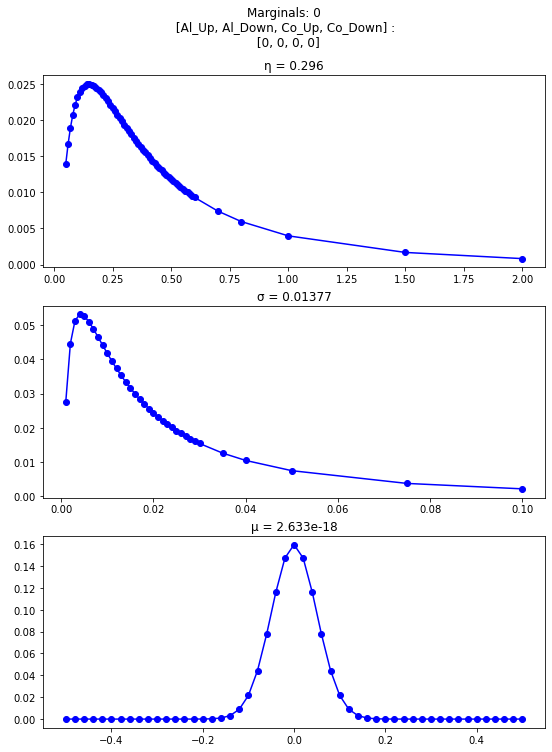

In [22]:

proc.init_px(list_DOL[0])
proc.plot_marginals

In [23]:

print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

proc.init_px_chg(list_DOL[1])

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

proc.plot_marginals

start
2020-10-22 19:02:07.157449


NotDefinedError: Failed in nopython mode pipeline (step: analyzing bytecode)
Variable 's0' is not defined.

File "uz.py", line 461:
def nprobmw(ud, sud, s, α, η, σ, μ, t, δt=0.0001):
    <source elided>
    else:
        if nprobw(ud, s0, s, α, η, σ, μ, 1) == 0:
        ^


In [27]:

print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

proc.update_with_counts(list_DOL[2])

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

proc.plot_marginals

In [28]:

uz2.nprobmw(1, -1, 3237.0, 0.5, 0.5, 0.001, 0.0, 2e-5)

In [35]:

dftest = uz_df.df_trades_adduz.copy()

dftest['Ptj'] = dftest['trade_price'].copy()
dftest['dtj'] = dftest['dtTj'].copy().dt.total_seconds()
dftest['Co'] = dftest['Co'] == 1
dftest['Al'] = dftest['Al'] == 1
dftest['seconds'] = (dftest['DateTime'] - dftest['DateTime'].iloc[0])\
    .dt.total_seconds()
dftest.set_index('seconds', inplace=True)

# dftest[['DateTime', 'trade_price']].set_index('DateTime').plot()

fitcme = uz2.fit_trio(dftest, TS_CME, 16, λ=1, show_charts=False)

dfroll, dfcum = uz2.stats_window(dftest, TS_CME, 16, λ=1, window_min=15,
                                 time_step_min=1)

Reading file /Users/marcoscscarreira/My Papers/UZModelUncertainty/CLOB_data/DOLG1720170119.csv
Re-formatting data
Remove data outside exchange trading hours
Armada Data Object Construction Successfull


In [ ]:

df2test = uz_df2.df_trades_adduz.copy()

df2test['Ptj'] = df2test['trade_price'].copy()
df2test['dtj'] = df2test['dtTj'].copy().dt.total_seconds()
df2test['Co'] = df2test['Co'] == 1
df2test['Al'] = df2test['Al'] == 1
df2test['seconds'] = (df2test['DateTime'] - df2test['DateTime'].iloc[0])\
    .dt.total_seconds()
df2test.set_index('seconds', inplace=True)

# df2test[['DateTime', 'trade_price']].set_index('DateTime').plot()

fitcme2 = uz2.fit_trio(df2test, TS_CME, 16, λ=1, show_charts=False)

df2roll, df2cum = uz2.stats_window(df2test, TS_CME, 16, λ=1, window_min=15,
                                   time_step_min=1)

In [ ]:

dftestDOL = uz_dfDOL.df_trades_adduz.copy()

dftestDOL['Ptj'] = dftestDOL['trade_price'].copy()
dftestDOL['dtj'] = dftestDOL['dtTj'].copy().dt.total_seconds()
dftestDOL['Co'] = dftestDOL['Co'] == 1
dftestDOL['Al'] = dftestDOL['Al'] == 1
dftestDOL['seconds'] = (dftestDOL['DateTime'] - dftestDOL['DateTime'].iloc[0])\
    .dt.total_seconds()
dftestDOL.set_index('seconds', inplace=True)

# dftestDOL[['DateTime', 'trade_price']].set_index('DateTime').plot()

fitdol = uz2.fit_trio(dftestDOL, TS_BMF, 9.25, λ=1, show_charts=False)

dfrollDOL, dfcumDOL = uz2.stats_window(dftestDOL, TS_BMF, 9.25, λ=1,
                                       window_min=15, time_step_min=1)

In [ ]:

dftestWDO = uz_dfWDO.df_trades_adduz.copy()

dftestWDO['Ptj'] = dftestWDO['trade_price'].copy()
dftestWDO['dtj'] = dftestWDO['dtTj'].copy().dt.total_seconds()
dftestWDO['Co'] = dftestWDO['Co'] == 1
dftestWDO['Al'] = dftestWDO['Al'] == 1
dftestWDO['seconds'] = (dftestWDO['DateTime'] - dftestWDO['DateTime'].iloc[0])\
    .dt.total_seconds()
dftestWDO.set_index('seconds', inplace=True)

# dftestWDO[['DateTime', 'trade_price']].set_index('DateTime').plot()

fitwdo = uz2.fit_trio(dftestWDO, TS_BMF, 9.25, λ=1, show_charts=False)

dfrollWDO, dfcumWDO = uz2.stats_window(dftestWDO, TS_BMF, 9.25, λ=1,
                                       window_min=15, time_step_min=1)

In [ ]:

def plot_stats(data_roll, data_cum, title):
    fig, axs = plt.subplots(4, 2, figsize=(18, 18))
    fig.suptitle(title, y=0.90)
    
    data_index = data_roll.index

    axs[0, 0].plot(data_roll[['η', 'H']])
    axs[0, 0].legend(['η', 'H'])
    axs[0, 0].set_title('η and H - Rolling')
    axs[0, 1].plot(data_cum[['η', 'H']])
    axs[0, 1].legend(['η', 'H'])
    axs[0, 1].set_title('η and H - Cumulative')
    
    axs[1, 0].plot(data_roll[['σ', 'σXe']])
    axs[1, 0].set_title('σ and σXe - Rolling')
    axs[1, 0].legend(['σ', 'σXe'])
    axs[1, 1].plot(data_cum[['σ', 'σXe']])
    axs[1, 1].legend(['σ', 'σXe'])
    axs[1, 1].set_title('σ and σXe - Cumulative')
    
    axs[2, 0].plot(data_roll[['μ']])
    axs[2, 0].legend(['μ'])
    axs[2, 0].set_title('μ - Rolling')
    axs[2, 1].plot(data_cum[['μ']])
    axs[2, 1].legend(['μ'])
    axs[2, 1].set_title('μ - Cumulative')
    
    axs[3, 0].plot(data_roll[['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down']])
    axs[3, 0].legend(['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down'])
    axs[3, 0].set_title('Frequencies - Rolling')
    axs[3, 1].plot(data_cum[['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down']])
    axs[3, 1].legend(['f_Al_Up', 'f_Co_Up', 'f_Al_Down', 'f_Co_Down'])
    axs[3, 1].set_title('Frequencies - Cumulative')

In [ ]:

plot_stats(dfroll, dfcum, 'CME 20180104')

In [ ]:

plot_stats(df2roll, df2cum, 'CME 20180105')

In [ ]:

plot_stats(dfrollDOL, dfcumDOL, 'DOL 20170119')

In [ ]:

plot_stats(dfrollWDO, dfcumWDO, 'WDO 20170119')

In [ ]:

ev_size = df_hawk.event_size_pivot()
sht.range('F2').value = ev_size

dmi_B, dmi_A = df_hawk.describe_DmI()
sht.range('N2').value = dmi_B
sht.range('N12').value = dmi_A

In [ ]:

trad_window_sec = df_hawk.get_trading_window()
sht.range('C19').value = trad_window_sec

event_counts = df_hawk.get_event_counts()
sht.range('X154').value = event_counts

In [ ]:

pivot_counts = df_hawk.pivot_events(piv_values='dt', aggfunc='count')
sht.range('E154').value = pivot_counts

pivot_dur_avg = df_hawk.pivot_events(piv_values='dt', aggfunc=np.mean)
sht.range('E172').value = pivot_dur_avg

pivot_dur_med = df_hawk.pivot_events(piv_values='dt', aggfunc=np.median)
sht.range('E188').value = pivot_dur_med

pivot_eventsize = df_hawk.pivot_events(piv_values='Event_Size')
sht.range('E206').value = pivot_eventsize

pivot_imbalance = df_hawk.pivot_prev_events(piv_values='Imbalance')
sht.range('E224').value = pivot_imbalance

pivot_sprticks = df_hawk.pivot_prev_events(piv_values='Spread_Ticks')
sht.range('E242').value = pivot_sprticks

In [ ]:


df_ts, df_lbls = df_hawk.get_event_timestamps()

In [ ]:

T0 = LATENCY_CME

kernel_disc_em_1 =\
    np.concatenate(
        (np.array([0., 0.000025,
                   0.25*T0, 0.5*T0, 0.75*T0, 0.9*T0, T0, 1.25*T0, 1.5*T0]),
         np.array([0.005, 0.01, 0.02, 0.05, 0.075, 0.1, 0.2, 0.5, 0.75,
                   1.0, 2.0, 5.0, 10.0])))
kernel_intervals_1 = np.diff(kernel_disc_em_1)

In [ ]:

em_1 = HawkesEM(kernel_discretization=kernel_disc_em_1, max_iter=10000,
                tol=1e-5, verbose=True, n_threads=-1)
em_1.fit(df_ts)

In [ ]:

em_1_baseline = em_1.baseline
sht.range('C116').value = np.transpose([em_1_baseline])

em_1_kernel = em_1.kernel
em_1_norms = em_1.get_kernel_norms()
sht.range('F116').value = em_1_norms

em_1_score = em_1.score()

In [ ]:

# def mult_dt_em1(x):
#     return x * kernel_intervals_1

# em_1_kerndt = np.array(list(map(mult_dt_em1, em_1_kernel)))

def norm_em1(x):
    return np.dot(x, kernel_intervals_1)

em_1_norms_all = np.array(list(map(norm_em1, em_1_kernel)))

kernel_intervals_1_b = kernel_intervals_1 *\
    np.concatenate((np.zeros(6), np.ones(15)))

def norm_before_em1(x):
    return np.dot(x, kernel_intervals_1_b)

em_1_norms_before = np.array(list(map(norm_before_em1, em_1_kernel)))
sht.range('F95').value = em_1_norms_before

kernel_intervals_1_a = kernel_intervals_1 *\
    np.concatenate((np.ones(6), np.zeros(15)))

def norm_after_em1(x):
    return np.dot(x, kernel_intervals_1_a)

em_1_norms_after = np.array(list(map(norm_after_em1, em_1_kernel)))
sht.range('F137').value = em_1_norms_after

norm_before = em_1_norms_before / em_1_norms_all

norm_after = em_1_norms_after / em_1_norms_all

norm_check = norm_before + norm_after

In [ ]:


def pivots_intensities(data_frame, max_q=20, plot_q=True, title=''):
    data_framec = data_frame.copy()
    data_frame_reinf = data_framec[~data_framec['Reversion']].copy()
    data_frame_rever = data_framec[data_framec['Reversion']].copy()

    def cols_intens(sub_data_frame):
        data_framec = sub_data_frame.copy()
        data_framec['ProvA'] = data_framec['La'] + data_framec['Pa-']
        data_framec['ProvB'] = data_framec['Lb'] + data_framec['Pb+']
        data_framec['DeplA'] = data_framec['PaC+'] + data_framec['PaM+']
        data_framec['DeplB'] = data_framec['PbC-'] + data_framec['PbM-']
        data_framec['ConsA'] = data_framec['Ma'] + data_framec['Ca'] +\
            data_framec['DeplA']
        data_framec['ConsB'] = data_framec['Mb'] + data_framec['Cb'] +\
            data_framec['DeplB']
        data_framec['CancA'] = data_framec['PaC+'] + data_framec['Ca']
        data_framec['CancB'] = data_framec['PbC-'] + data_framec['Cb']
        data_framec['TradA'] = data_framec['Ma'] + data_framec['PaM+']
        data_framec['TradB'] = data_framec['Mb'] + data_framec['PbM-']
        data_framec['Provision'] = data_framec['ProvA'] +\
            data_framec['ProvB']
        data_framec['Consumption'] = data_framec['ConsA'] +\
            data_framec['ConsB']
        data_framec['Cancel'] = data_framec['CancA'] +\
            data_framec['CancB']
        data_framec['Trade'] = data_framec['TradA'] +\
            data_framec['TradB']
        return data_framec

    def create_pivots(sub_data_frame):
        sub_df_bid_count = cols_intens(pd.pivot_table(
            sub_data_frame, values='Reversion', index=['bid_1_qty'],
            columns='Event_detail', aggfunc='count', margins=False).fillna(0))
        sub_df_ask_count = cols_intens(pd.pivot_table(
            sub_data_frame, values='Reversion', index=['ask_1_qty'],
            columns='Event_detail', aggfunc='count', margins=False).fillna(0))
        sub_df_bid_dt = cols_intens(pd.pivot_table(
            sub_data_frame, values='dt', index=['bid_1_qty'],
            columns='Event_detail', aggfunc=np.sum, margins=False).fillna(0))
        sub_df_ask_dt = cols_intens(pd.pivot_table(
            sub_data_frame, values='dt', index=['ask_1_qty'],
            columns='Event_detail', aggfunc=np.sum, margins=False).fillna(0))
        return [sub_df_bid_count, sub_df_ask_count, sub_df_bid_dt,
                sub_df_ask_dt]

    df_all_bid_count, df_all_ask_count, df_all_bid_dt, df_all_ask_dt =\
        create_pivots(data_framec)
    df_rein_bid_count, df_rein_ask_count, df_rein_bid_dt, df_rein_ask_dt =\
        create_pivots(data_frame_reinf)
    df_reve_bid_count, df_reve_ask_count, df_reve_bid_dt, df_reve_ask_dt =\
        create_pivots(data_frame_rever)

    def average_bid_ask(data_frame_bid, data_frame_ask):
        cols_df = ['ProvA', 'ProvB', 'ConsA', 'ConsB', 'DeplA', 'DeplB',
                   'CancA', 'CancB', 'TradA', 'TradB', 'Provision',
                   'Consumption', 'Cancel', 'Trade']
        cols_bid = {'ProvA': 'Prov-', 'ProvB': 'Prov+', 'ConsA': 'Cons-',
                    'ConsB': 'Cons+', 'DeplA': 'Depl-', 'DeplB': 'Depl+',
                    'CancA': 'Canc-', 'CancB': 'Canc+', 'TradA': 'Trad-',
                    'TradB': 'Trad+'}
        cols_ask = {'ProvA': 'Prov+', 'ProvB': 'Prov-', 'ConsA': 'Cons+',
                    'ConsB': 'Cons-', 'DeplA': 'Depl+', 'DeplB': 'Depl-',
                    'CancA': 'Canc+', 'CancB': 'Canc-', 'TradA': 'Trad+',
                    'TradB': 'Trad-'}
        data_frame_bidc = data_frame_bid[cols_df].copy().rename(
            columns=cols_bid)
        data_frame_askc = data_frame_ask[cols_df].copy().rename(
            columns=cols_ask)
        data_frame_avg = (data_frame_bidc.add(data_frame_askc))/2
        return data_frame_avg

    df_all_count = average_bid_ask(df_all_bid_count, df_all_ask_count)
    df_all_dt = average_bid_ask(df_all_bid_dt, df_all_ask_dt)
    df_all_intens = df_all_count / df_all_dt
    df_all_dur = df_all_dt / df_all_count

    df_rein_count = average_bid_ask(df_rein_bid_count, df_rein_ask_count)
    df_rein_dt = average_bid_ask(df_rein_bid_dt, df_rein_ask_dt)
    df_rein_intens = df_rein_count / df_rein_dt
    df_rein_dur = df_rein_dt / df_rein_count

    df_reve_count = average_bid_ask(df_reve_bid_count, df_reve_ask_count)
    df_reve_dt = average_bid_ask(df_reve_bid_dt, df_reve_ask_dt)
    df_reve_intens = df_reve_count / df_reve_dt
    df_reve_dur = df_reve_dt / df_reve_count

    def plot_intensity(data_frame, cols, title_plot):
        sub_df_plot = data_frame[cols].copy().iloc[:max_q]
        sub_df_plot.plot(title=title + title_plot, figsize=(15, 10))

    if plot_q:

        # cols_cp = ['Consumption', 'Provision']
        cols_agg = ['Cancel', 'Provision', 'Trade']
        cols_all = ['Canc+', 'Prov+', 'Trad+', 'Canc-', 'Prov-', 'Trad-']

        title_count = ' - Events by queue size - count'
        # plot_intensity(df_all_count, cols=cols_cp, title_plot=title_count)
        plot_intensity(df_all_count, cols=cols_agg, title_plot=title_count)
        plot_intensity(df_all_count, cols=cols_all, title_plot=title_count)
        title_intens = ' - Events by queue size - intensity'
        # plot_intensity(df_all_intens, cols=cols_cp, title_plot=title_intens)
        plot_intensity(df_all_intens, cols=cols_agg, title_plot=title_intens)
        plot_intensity(df_all_intens, cols=cols_all, title_plot=title_intens)
        title_dur = ' - Events by queue size - durations'
        # plot_intensity(df_all_dur, cols=cols_cp, title_plot=title_dur)
        plot_intensity(df_all_dur, cols=cols_agg, title_plot=title_dur)
        plot_intensity(df_all_dur, cols=cols_all, title_plot=title_dur)

        title_count_rein = ' - Events by queue size - count - Reinforce'
        # plot_intensity(df_rein_count, cols=cols_cp,
        #                title_plot=title_count_rein)
        plot_intensity(df_rein_count, cols=cols_agg,
                       title_plot=title_count_rein)
        plot_intensity(df_rein_count, cols=cols_all,
                       title_plot=title_count_rein)
        title_intens_rein = ' - Events by queue size - intensity - Reinforce'
        # plot_intensity(df_rein_intens, cols=cols_cp,
        #                title_plot=title_intens_rein)
        plot_intensity(df_rein_intens, cols=cols_agg,
                       title_plot=title_intens_rein)
        plot_intensity(df_rein_intens, cols=cols_all,
                       title_plot=title_intens_rein)
        title_dur_rein = ' - Events by queue size - durations - Reinforce'
        # plot_intensity(df_rein_dur, cols=cols_cp,
        #                title_plot=title_dur_rein)
        plot_intensity(df_rein_dur, cols=cols_agg,
                       title_plot=title_dur_rein)
        plot_intensity(df_rein_dur, cols=cols_all,
                       title_plot=title_dur_rein)

        title_count_reve = ' - Events by queue size - count - Revert'
        # plot_intensity(df_rein_count, cols=cols_cp,
        #                title_plot=title_count_reve)
        plot_intensity(df_reve_count, cols=cols_agg,
                       title_plot=title_count_reve)
        plot_intensity(df_reve_count, cols=cols_all,
                       title_plot=title_count_reve)
        title_intens_reve = ' - Events by queue size - intensity - Revert'
        # plot_intensity(df_reve_intens, cols=cols_cp,
        #                title_plot=title_intens_reve)
        plot_intensity(df_reve_intens, cols=cols_agg,
                       title_plot=title_intens_reve)
        plot_intensity(df_reve_intens, cols=cols_all,
                       title_plot=title_intens_reve)
        title_dur_reve = ' - Events by queue size - durations - Revert'
        # plot_intensity(df_reve_dur, cols=cols_cp,
        #                title_plot=title_dur_reve)
        plot_intensity(df_reve_dur, cols=cols_agg,
                       title_plot=title_dur_reve)
        plot_intensity(df_reve_dur, cols=cols_all,
                       title_plot=title_dur_reve)

In [ ]:


# pivots_intensities(dfDOL, 25, True, 'DOL 2017-01-19')

# pivots_intensities(dfWDO, 60, True, 'WDO 2017-01-19')

# pivots_intensities(dfCME1, 25, 'CME 2018-01-05')

# pivots_intensities(dfCME2, 25, 'CME 2018-01-04')

In [ ]:

len(em_1_kernel[0][0])

In [ ]:

plot_hawkes_kernels(em_1, log_scale=True)

In [ ]:

# hawkes_reversion = get_hawkes(dfDOL.iloc[1:], 'Reversion', True)
# hawkes_ask = get_hawkes(dfDOL.iloc[1:], 'AskQ', True)
# hawkes_cons = get_hawkes(dfDOL.iloc[1:], 'ConsQ', True)
# hawkes_imbal = get_hawkes(dfDOL.iloc[1:], 'Imbal_Sign', True)

# ts_14, lbls_14 = get_event_timestamps(dfDOL.iloc[1:], 'Event_12')

hawkes_event_DOL = get_hawkes_events(dfDOL.iloc[1:], plot=False)

hawkes_event_WDO = get_hawkes_events(dfWDO.iloc[1:], plot=False)

df_intens = pd.DataFrame(
    {'DOL baseline': hawkes_event_DOL[0],
     'WDO baseline': hawkes_event_WDO[0],
     'DOL mean int': hawkes_event_DOL[1],
     'WDO mean int': hawkes_event_WDO[1],
     'DOL ratios': hawkes_event_DOL[2],
     'WDO ratios': hawkes_event_WDO[2]},
    index=EV_14_LBLS)

sns.heatmap(df_intens.transpose(), center=0, cmap='RdBu', annot=True,
            fmt=".3f")

sns.heatmap(hawkes_event_DOL[3], center=0, cmap='RdBu',
            annot=True, fmt=".3f",
            xticklabels=EV_14_LBLS, yticklabels=EV_14_LBLS)

sns.heatmap(hawkes_event_WDO[3], center=0, cmap='RdBu',
            annot=True, fmt=".3f",
            xticklabels=EV_14_LBLS, yticklabels=EV_14_LBLS)

df_intens.to_csv(PATHOUT+'df_intens_BMF.csv')

pd.DataFrame(hawkes_event_DOL[3], columns=EV_14_LBLS, index=EV_14_LBLS)\
    .to_csv(PATHOUT+'df_norms_DOL.csv')
pd.DataFrame(hawkes_event_WDO[3], columns=EV_14_LBLS, index=EV_14_LBLS)\
    .to_csv(PATHOUT+'df_norms_WDO.csv')

In [ ]:


FILES_DOL = [
    'DOLG1720170103.csv', 'DOLG1720170104.csv',
    'DOLG1720170105.csv', 'DOLG1720170106.csv', 'DOLG1720170109.csv',
    'DOLG1720170110.csv', 'DOLG1720170111.csv', 'DOLG1720170112.csv',
    'DOLG1720170113.csv', 'DOLG1720170116.csv', 'DOLG1720170117.csv',
    'DOLG1720170118.csv', 'DOLG1720170119.csv', 'DOLG1720170120.csv',
    'DOLG1720170123.csv', 'DOLG1720170124.csv', 'DOLG1720170126.csv',
    'DOLG1720170127.csv', 'DOLG1720170130.csv',
    'DOLH1720170131.csv',
    'DOLH1720170201.csv', 'DOLH1720170202.csv', 'DOLH1720170203.csv',
    'DOLH1720170207.csv', 'DOLH1720170208.csv', \
    'DOLH1720170209.csv', 'DOLH1720170210.csv', 'DOLH1720170213.csv',
    'DOLH1720170214.csv', 'DOLH1720170215.csv', 'DOLH1720170216.csv',
    'DOLH1720170217.csv', 'DOLH1720170220.txt', 'DOLH1720170221.txt',
    'DOLH1720170222.txt', 'DOLH1720170223.txt']

FILES_WDO = [
    'WDOG1720170103.csv', 'WDOG1720170104.csv',
    'WDOG1720170105.csv', 'WDOG1720170106.csv', 'WDOG1720170109.csv',
    'WDOG1720170110.csv', 'WDOG1720170111.csv', 'WDOG1720170112.csv',
    'WDOG1720170113.csv', 'WDOG1720170116.csv', 'WDOG1720170117.csv',
    'WDOG1720170118.csv', 'WDOG1720170119.csv', 'WDOG1720170120.csv',
    'WDOG1720170123.csv', 'WDOG1720170124.csv', 'WDOG1720170126.csv',
    'WDOG1720170127.csv', 'WDOG1720170130.csv',
    'WDOH1720170131.csv',
    'WDOH1720170201.csv', 'WDOH1720170202.csv', 'WDOH1720170203.csv',
    'WDOH1720170207.csv', 'WDOH1720170208.csv',
    'WDOH1720170209.csv', 'WDOH1720170210.csv', 'WDOH1720170213.csv',
    'WDOH1720170214.csv', 'WDOH1720170215.csv', 'WDOH1720170216.csv',
    'WDOH1720170217.csv', 'WDOH1720170220.txt', 'WDOH1720170221.txt',
    'WDOH1720170222.txt', 'WDOH1720170223.txt']

FILES_CME = [
    '20180102_6EH8.zip', '20180103_6EH8.zip',
    '20180104_6EH8.zip', '20180105_6EH8.zip']

In [ ]:


def get_hawkes_events_list(
        pathin, pathout, file_list, tick_value, min_order_size, start_time,
        end_time, file_type='CME', min_dt=MINDTCME, dt_shift=DTEVSHIFTCME,
        dt_cum_shift=DTCUMADDCME, save_files=False, plot=False):
    df_list = [initall(
        pathin, pathout, file, tick_value, min_order_size, start_time,
        end_time, file_type, min_dt, dt_shift, dt_cum_shift, save_files)
        for file in file_list]
    timestamps = [get_event_14_timestamps(df)[0] for df in df_list]
    hawkes_learner = HawkesConditionalLaw(
        claw_method="log", delta_lag=0.1, min_lag=5e-4, max_lag=500,
        quad_method="log", n_quad=10, min_support=1e-4, max_support=1,
        n_threads=-1)
    hawkes_learner.set_model(symmetries1d=symmetries1d,
                             symmetries2d=symmetries2d)
    hawkes_learner.fit(timestamps)
    if plot:
        plot_hawkes_kernel_norms(hawkes_learner, node_names=EV_14_LBLS)
    hbase = hawkes_learner.baseline
    hmean = hawkes_learner.mean_intensity
    hnorms = hawkes_learner.kernels_norms
    return [hbase, hmean, hbase/hmean, hnorms]


def prepare_hawkes_EM_events_list(
        pathin, pathout, file_list, tick_value, min_order_size, start_time,
        end_time, file_type='CME', min_dt=MINDTCME,
        dt_shift=DTEVSHIFTCME, dt_cum_shift=DTCUMADDCME):
    df_list = [initall(
        pathin, pathout, file, tick_value, min_order_size, start_time,
        end_time, file_type, min_dt, dt_shift, dt_cum_shift, False)
        for file in file_list]
    timestamps = [get_event_14_timestamps(df)[0] for df in df_list]
    return timestamps


def get_hawkes_EM(timestamps, kernel_discretization, baseline_start,
                  n_threads=4, max_iter=100, verbose=True, tol=1e-5):
    hkem = HawkesEM(kernel_discretization=kernel_discretization,
                    n_threads=n_threads, max_iter=max_iter, verbose=verbose,
                    tol=tol)
    hkem.fit(timestamps, baseline_start=baseline_start)
    return [hkem.baseline, hkem.kernel, hkem.get_kernel_norms()]

# def get_hawkes_EM_events_list(
#         pathin, pathout, file_list, tick_value, min_order_size, start_time,
#         end_time, kernel_support=2, kernel_size=20, n_threads=4, max_iter=100,
#         verbose=True, tol=1e-5, file_type='CME', min_dt=MINDTCME,
#         dt_shift=DTEVSHIFTCME, dt_cum_shift=DTCUMADDCME,):
#     df_list = [initall(
#         pathin, pathout, file, tick_value, min_order_size, start_time,
#         end_time, file_type, min_dt, dt_shift, dt_cum_shift, False)
#         for file in file_list]
#     timestamps = [get_event_14_timestamps(df)[0] for df in df_list]
#     hkem = HawkesEM(kernel_support=kernel_support, kernel_size=kernel_size,
#                   n_threads=n_threads, max_iter=max_iter, verbose=verbose,
#                   tol=tol)
#     hkem.fit(timestamps)
#     return [hkem.baseline, hkem.kernel]

In [ ]:

# hawkes_event_DOLs = get_hawkes_events_list(
#     PATHIN, PATHOUT, FILES_DOL, TS1, MOSDOL, START_TIME1, END_TIME1, 'BMF',
#     MINDT1, False, [], [], False)

# sns.heatmap(hawkes_event_DOLs[3], center=0, cmap='RdBu',
#             annot=True, fmt=".2f",
#             xticklabels=EV_14_LBLS, yticklabels=EV_14_LBLS)

# hawkes_event_WDOs = get_hawkes_events_list(
#     PATHIN, PATHOUT, FILES_WDO, TS1, MOSWDO, START_TIME1, END_TIME1, 'BMF',
#     MINDT1, False, [], [], False)

# sns.heatmap(hawkes_event_WDOs[3], center=0, cmap='RdBu',
#             annot=True, fmt=".2f",
#             xticklabels=EV_14_LBLS, yticklabels=EV_14_LBLS)

In [ ]:


# EM_DOLs_baseline, EM_DOLs_kernels = get_hawkes_EM_events_list(
#     PATHIN, PATHOUT, FILES_DOL, TS1, MOSDOL, START_TIME1, END_TIME1, 2, 20,
#     4, 100, True, 1e-5, 'BMF', MINDT1)

# EM_WDOs_baseline, EM_WDOs_kernels = get_hawkes_EM_events_list(
#     PATHIN, PATHOUT, FILES_WDO, TS1, MOSWDO, START_TIME1, END_TIME1, 2, 20,
#     4, 100, True, 1e-5, 'BMF', MINDT1)

In [ ]:


def runc_multi_days(pathin, pathout, tick_value, start_time, end_time,
                    file_names=[], file_type='CME', min_dt=MINDTCME):
    """Run uz_stats for multiple days.

    runc_multi_days(pathin, pathout, tick_value, start_time, end_time,
                    file_names=[], file_type='CME', save_files=False)
    returns the UZ stats for multiple days
    """
    # tick_value = TS
    # filepaths = [pathout]
    # # create directories if do not exist
    # for path in filepaths:
    #     if not os.path.exists(path):
    #         os.makedirs(path)
    # # either explicitly set file_names or get file_names from data path
    # if len(file_names) == 0:
    #     for file in os.listdir(pathin):
    #         if file.endswith("csv") or file.endswith(".zip"):
    #             file_names.append(file)
    for f_name in file_names:
        # start = timeit.default_timer()
        print('--START------')
        data = ad(pathin, f_name, file_type)
        dataadj = al1(data, start_time, end_time, file_type, min_dt)
        uz_obj = uz(dataadj, tick_value, start_time, end_time)
        if file_names[0] == f_name:
            output = uz_obj.get_Armada_UZModel_output()
        else:
            output.append(uz_obj.get_Armada_UZModel_output())
        # stop = timeit.default_timer()
        # print('Time Spent: ', round(stop - start), ' seconds')
        print('--END-------')
    output.print2file_df_cont_alt_by_ticks(pathout)
    output.print2file_df_uz_stats(pathout)
    output.plot_html_uz_stats(pathout)

In [ ]:

runc_multi_days(PATHIN, PATHOUT, TS1, START_TIME1, END_TIME1,
                    file_names=FILES_DOL, file_type='BMF', min_dt=MINDT1)

# Rename files before running again!

runc_multi_days(PATHIN, PATHOUT, TS1, START_TIME1, END_TIME1,
                    file_names=FILES_WDO, file_type='BMF', min_dt=MINDT1)

# Rename files before running again!

runc_multi_days(PATHIN, PATHOUT, TS, START_TIME, END_TIME,
                    file_names=FILES_CME, file_type='CME', min_dt=MINDTCME)

In [ ]:


EM_DOLs_timestamps = prepare_hawkes_EM_events_list(
    PATHIN, PATHOUT, FILES_DOL, TS1, MOSDOL, START_TIME1, END_TIME1, 'BMF',
    min_dt=MINDT1, dt_shift=DTEVSHIFT1, dt_cum_shift=DTCUMADD1)

EM_WDOs_timestamps = prepare_hawkes_EM_events_list(
    PATHIN, PATHOUT, FILES_WDO, TS1, MOSWDO, START_TIME1, END_TIME1, 'BMF',
    min_dt=MINDT1, dt_shift=DTEVSHIFT1, dt_cum_shift=DTCUMADD1)

for j in range(len(EM_DOLs_timestamps)):
    np.save(PATHOUT+'TS_'+FILES_DOL[j][:-4], EM_DOLs_timestamps[j])
    np.save(PATHOUT+'TS_'+FILES_WDO[j][:-4], EM_WDOs_timestamps[j])

In [ ]:


EM_CME_timestamps = prepare_hawkes_EM_events_list(
    PATHIN, PATHOUT, FILES_CME, TS, MOSCME, START_TIME, END_TIME, 'CME',
    min_dt=MINDTCME, dt_shift=DTEVSHIFTCME, dt_cum_shift=DTCUMADDCME)

for j in range(len(EM_CME_timestamps)):
    np.save(PATHOUT+'TS_'+FILES_CME[j][:-4], EM_CME_timestamps[j])

In [ ]:


EM_DOLs_timestamps_S = [list(np.load(PATHOUT + 'TS_' + file[:-4] + '.npy',
                                     allow_pickle=True))
                        for file in FILES_DOL]

EM_WDOs_timestamps_S = [list(np.load(PATHOUT + 'TS_' + file[:-4] + '.npy',
                                     allow_pickle=True))
                        for file in FILES_WDO]

EM_CME_timestamps_S = [list(np.load(PATHOUT + 'TS_' + file[:-4] + '.npy',
                                    allow_pickle=True))
                       for file in FILES_CME]

In [ ]:

n_threads = -1
verbose_EM = True
max_iter = 1000
tol = 1e-5
baseline_start = np.array([1., 1., 0.1, 0., 0., 0., 0.,
                           1., 1., 0.1, 0., 0., 0., 0.])

In [ ]:


kernel_discretization =\
    np.concatenate(
        (np.linspace(0.001, 0.01, 9, endpoint=False),
         np.linspace(0.01, 0.1, 9, endpoint=False),
         np.linspace(0.1, 1.0, 9, endpoint=False),
         np.linspace(1.0, 5.0, 16+1)))
kernel_intervals = np.concatenate((np.array([0.001]),
                                   np.diff(kernel_discretization)))

kernel_discretization_2 =\
    np.concatenate(
        (np.array([0.000025, 0.00075]),
         np.linspace(0.001, 0.01, 9, endpoint=False),
         np.linspace(0.01, 0.1, 9, endpoint=False),
         np.linspace(0.1, 1.0, 9, endpoint=False),
         np.linspace(1.0, 5.0, 16+1)))
kernel_intervals_2 = np.concatenate((np.array([0.000025]),
                                     np.diff(kernel_discretization_2)))

kernel_discretization_3 =\
    np.array([0.000025, 0.00075, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05,
              0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
kernel_intervals_3 = np.concatenate((np.array([0.000025]),
                                     np.diff(kernel_discretization_3)))

In [ ]:


kernel_discretization_CME =\
    np.concatenate(
        (np.linspace(0.0000001, 0.000001, 9, endpoint=False),
         np.linspace(0.000001, 0.00001, 9, endpoint=False),
         np.linspace(0.00001, 0.0001, 9, endpoint=False),
         np.linspace(0.0001, 0.001, 9, endpoint=False),
         np.linspace(0.001, 0.01, 9, endpoint=False),
         np.linspace(0.01, 0.1, 9, endpoint=False),
         np.linspace(0.1, 1.0, 9, endpoint=False),
         np.linspace(1.0, 2.0, 4+1)))
kernel_intervals_CME = np.concatenate((np.array([0.0000001]),
                                       np.diff(kernel_discretization_CME)))

kernel_discretization_CME_2 =\
     np.array([2.5e-07, 5.0e-07, 1.0e-06, 2.0e-06, 5.0e-06, 1.0e-05,
              2.0e-05, 5.0e-05, 1.0e-04, 2.0e-04, 5.0e-04, 1.0e-03, 2.0e-03,
              5.0e-03, 1.0e-02, 2.0e-02, 5.0e-02, 1.0e-01, 2.0e-01, 5.0e-01,
              1.0, 2.0, 5.0])
kernel_intervals_CME_2 = np.concatenate((np.array([2.5e-07]),
                                         np.diff(kernel_discretization_CME_2)))

In [ ]:


em_DOLs_baseline_1, em_DOLs_kernel_1, em_DOLs_kernel_norms_1 =\
    get_hawkes_EM(EM_DOLs_timestamps_S,
                  kernel_discretization=kernel_discretization,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_DOLs_baseline_1 = pd.Series(em_DOLs_baseline_1, index=EV_14_LBLS)
em_DOLs_baseline_1.to_csv(PATHOUT+'em_DOLs_baseline_1.csv')
em_DOLs_kernel_norms_1 = pd.DataFrame(em_DOLs_kernel_norms_1,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_DOLs_kernel_norms_1.to_csv(PATHOUT+'em_DOLs_kernel_norms_1.csv')
np.save(PATHOUT+'em_DOLs_kernel_1', em_DOLs_kernel_1)

em_WDOs_baseline_1, em_WDOs_kernel_1, em_WDOs_kernel_norms_1 =\
    get_hawkes_EM(EM_WDOs_timestamps_S,
                  kernel_discretization=kernel_discretization,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_WDOs_baseline_1 = pd.Series(em_WDOs_baseline_1, index=EV_14_LBLS)
em_WDOs_baseline_1.to_csv(PATHOUT+'em_WDOs_baseline_1.csv')
em_WDOs_kernel_norms_1 = pd.DataFrame(em_WDOs_kernel_norms_1,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_WDOs_kernel_norms_1.to_csv(PATHOUT+'em_WDOs_kernel_norms_1.csv')
np.save(PATHOUT+'em_WDOs_kernel_1', em_WDOs_kernel_1)

In [ ]:


em_DOLs_baseline_S = pd.read_csv(PATHOUT+'em_DOLs_baseline_1.csv',
                                 index_col=0, squeeze=True)
em_DOLs_kernel_norms_S = pd.read_csv(PATHOUT+'em_DOLs_kernel_norms_1.csv',
                                     index_col=0)
em_DOLs_kernel_S = np.load(PATHOUT + 'em_DOLs_kernel_1.npy',
                           allow_pickle=True)

em_WDOs_baseline_S = pd.read_csv(PATHOUT+'em_WDOs_baseline_1.csv',
                                 index_col=0, squeeze=True)
em_WDOs_kernel_norms_S = pd.read_csv(PATHOUT+'em_WDOs_kernel_norms_1.csv',
                                     index_col=0)
em_WDOs_kernel_S = np.load(PATHOUT + 'em_WDOs_kernel_1.npy',
                           allow_pickle=True)

In [ ]:


em_DOLs_baseline_2, em_DOLs_kernel_2, em_DOLs_kernel_norms_2 =\
    get_hawkes_EM(EM_DOLs_timestamps_S,
                  kernel_discretization=kernel_discretization_2,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_DOLs_baseline_2 = pd.Series(em_DOLs_baseline_2, index=EV_14_LBLS)
em_DOLs_baseline_2.to_csv(PATHOUT+'em_DOLs_baseline_2.csv')
em_DOLs_kernel_norms_2 = pd.DataFrame(em_DOLs_kernel_norms_2,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_DOLs_kernel_norms_2.to_csv(PATHOUT+'em_DOLs_kernel_norms_2.csv')
np.save(PATHOUT+'em_DOLs_kernel_2', em_DOLs_kernel_2)

em_WDOs_baseline_2, em_WDOs_kernel_2, em_WDOs_kernel_norms_2 =\
    get_hawkes_EM(EM_WDOs_timestamps_S,
                  kernel_discretization=kernel_discretization_2,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_WDOs_baseline_2 = pd.Series(em_WDOs_baseline_2, index=EV_14_LBLS)
em_WDOs_baseline_2.to_csv(PATHOUT+'em_WDOs_baseline_2.csv')
em_WDOs_kernel_norms_2 = pd.DataFrame(em_WDOs_kernel_norms_2,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_WDOs_kernel_norms_2.to_csv(PATHOUT+'em_WDOs_kernel_norms_2.csv')
np.save(PATHOUT+'em_WDOs_kernel_2', em_WDOs_kernel_2)

In [ ]:


em_DOLs_baseline_2S = pd.read_csv(PATHOUT+'em_DOLs_baseline_2.csv',
                                  index_col=0, squeeze=True)
em_DOLs_kernel_norms_2S = pd.read_csv(PATHOUT+'em_DOLs_kernel_norms_2.csv',
                                      index_col=0)
em_DOLs_kernel_2S = np.load(PATHOUT + 'em_DOLs_kernel_2.npy',
                            allow_pickle=True)

em_WDOs_baseline_2S = pd.read_csv(PATHOUT+'em_WDOs_baseline_2.csv',
                                  index_col=0, squeeze=True)
em_WDOs_kernel_norms_2S = pd.read_csv(PATHOUT+'em_WDOs_kernel_norms_2.csv',
                                      index_col=0)
em_WDOs_kernel_2S = np.load(PATHOUT + 'em_WDOs_kernel_2.npy',
                            allow_pickle=True)

In [ ]:


em_DOLs_baseline_3, em_DOLs_kernel_3, em_DOLs_kernel_norms_3 =\
    get_hawkes_EM(EM_DOLs_timestamps_S,
                  kernel_discretization=kernel_discretization_3,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_DOLs_baseline_3 = pd.Series(em_DOLs_baseline_3, index=EV_14_LBLS)
em_DOLs_baseline_3.to_csv(PATHOUT+'em_DOLs_baseline_3.csv')
em_DOLs_kernel_norms_3 = pd.DataFrame(em_DOLs_kernel_norms_3,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_DOLs_kernel_norms_3.to_csv(PATHOUT+'em_DOLs_kernel_norms_3.csv')
np.save(PATHOUT+'em_DOLs_kernel_3', em_DOLs_kernel_3)

em_WDOs_baseline_3, em_WDOs_kernel_3, em_WDOs_kernel_norms_3 =\
    get_hawkes_EM(EM_WDOs_timestamps_S,
                  kernel_discretization=kernel_discretization_3,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_WDOs_baseline_3 = pd.Series(em_WDOs_baseline_3, index=EV_14_LBLS)
em_WDOs_baseline_3.to_csv(PATHOUT+'em_WDOs_baseline_3.csv')
em_WDOs_kernel_norms_3 = pd.DataFrame(em_WDOs_kernel_norms_3,
                                      index=EV_14_LBLS, columns=EV_14_LBLS)
em_WDOs_kernel_norms_3.to_csv(PATHOUT+'em_WDOs_kernel_norms_3.csv')
np.save(PATHOUT+'em_WDOs_kernel_3', em_WDOs_kernel_3)

In [ ]:


em_DOLs_baseline_3S = pd.read_csv(PATHOUT+'em_DOLs_baseline_3.csv',
                                  index_col=0, squeeze=True)
em_DOLs_kernel_norms_3S = pd.read_csv(PATHOUT+'em_DOLs_kernel_norms_3.csv',
                                      index_col=0)
em_DOLs_kernel_3S = np.load(PATHOUT + 'em_DOLs_kernel_3.npy',
                            allow_pickle=True)

em_WDOs_baseline_3S = pd.read_csv(PATHOUT+'em_WDOs_baseline_3.csv',
                                  index_col=0, squeeze=True)
em_WDOs_kernel_norms_3S = pd.read_csv(PATHOUT+'em_WDOs_kernel_norms_3.csv',
                                      index_col=0)
em_WDOs_kernel_3S = np.load(PATHOUT + 'em_WDOs_kernel_3.npy',
                            allow_pickle=True)

In [ ]:


pd.Series(em_DOLs_kernel_S[0, 0],
          index=kernel_discretization[1:]).loc[:0.01]

pd.Series(em_DOLs_kernel_2S[0, 0],
          index=kernel_discretization_2[1:]).loc[:0.01]

pd.Series(em_DOLs_kernel_3S[0, 0],
          index=kernel_discretization_3[1:]).loc[:0.01]

pd.Series(em_WDOs_kernel_S[0, 0],
          index=kernel_discretization[1:]).loc[:0.01]

pd.Series(em_DOLs_kernel_S[0, 0],
          index=kernel_discretization[1:]).loc[0.01:]

pd.Series(em_WDOs_kernel_S[0, 0],
          index=kernel_discretization[1:]).loc[0.01:]

In [ ]:


em_CME_baseline_1, em_CME_kernel_1, em_CME_kernel_norms_1 =\
    get_hawkes_EM(EM_CME_timestamps,
                  kernel_discretization=kernel_discretization_CME,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_CME_baseline_1 = pd.Series(em_CME_baseline_1, index=EV_14_LBLS)
em_CME_baseline_1.to_csv(PATHOUT+'em_CME_baseline_1.csv')
em_CME_kernel_norms_1 = pd.DataFrame(em_CME_kernel_norms_1,
                                     index=EV_14_LBLS, columns=EV_14_LBLS)
em_CME_kernel_norms_1.to_csv(PATHOUT+'em_CME_kernel_norms_1.csv')
np.save(PATHOUT+'em_CME_kernel_1', em_CME_kernel_1)

In [ ]:


em_CME_baseline_S = pd.read_csv(PATHOUT+'em_CME_baseline_1.csv',
                                 index_col=0, squeeze=True)
em_CME_kernel_norms_S = pd.read_csv(PATHOUT+'em_CME_kernel_norms_1.csv',
                                     index_col=0)
em_CME_kernel_S = np.load(PATHOUT + 'em_CME_kernel_1.npy',
                           allow_pickle=True)

In [ ]:


em_CME_baseline_2, em_CME_kernel_2, em_CME_kernel_norms_2 =\
    get_hawkes_EM(EM_CME_timestamps,
                  kernel_discretization=kernel_discretization_CME_2,
                  baseline_start=baseline_start,
                  n_threads=n_threads, max_iter=max_iter,
                  verbose=verbose_EM, tol=tol)
em_CME_baseline_2 = pd.Series(em_CME_baseline_2, index=EV_14_LBLS)
em_CME_baseline_2.to_csv(PATHOUT+'em_CME_baseline_2.csv')
em_CME_kernel_norms_2 = pd.DataFrame(em_CME_kernel_norms_2,
                                     index=EV_14_LBLS, columns=EV_14_LBLS)
em_CME_kernel_norms_2.to_csv(PATHOUT+'em_CME_kernel_norms_2.csv')
np.save(PATHOUT+'em_CME_kernel_2', em_CME_kernel_2)

In [ ]:


em_CME_baseline_2S = pd.read_csv(PATHOUT+'em_CME_baseline_2.csv',
                                 index_col=0, squeeze=True)
em_CME_kernel_norms_2S = pd.read_csv(PATHOUT+'em_CME_kernel_norms_2.csv',
                                     index_col=0)
em_CME_kernel_2S = np.load(PATHOUT + 'em_CME_kernel_2.npy',
                           allow_pickle=True)

In [ ]:


pd.Series(em_CME_kernel_S[0, 0],
          index=kernel_discretization_CME[1:]).loc[0.0000003:0.00001].plot()

pd.Series(em_CME_kernel_2S[0, 0],
          index=kernel_discretization_CME_2[1:]).loc[0.0000003:0.00001].plot()

pd.Series(em_CME_kernel_S[0, 0],
          index=kernel_discretization_CME[1:]).loc[0.00001:0.001].plot()

pd.Series(em_CME_kernel_2S[0, 0],
          index=kernel_discretization_CME_2[1:]).loc[0.00001:0.001].plot()

pd.Series(em_CME_kernel_S[0, 0],
          index=kernel_discretization_CME[1:]).loc[0.001:0.1].plot()

pd.Series(em_CME_kernel_2S[0, 0],
          index=kernel_discretization_CME_2[1:]).loc[0.001:0.1].plot()

In [ ]:


def expkBMF(t, a1, b1, a2, b2):
    kern1 = a1 * b1 * np.exp(-b1 * (t - DTCUMADD1.total_seconds()))
    kern2 = a2 * b2 * np.exp(-b2 * (t - DTCUMADD1.total_seconds()))
    return np.log(kern1 + kern2)

def expkCME(t, a1, b1, a2, b2):
    kern1 = a1 * b1 * np.exp(-b1 * (t - 20*DTCUMADDCME.total_seconds()))
    kern2 = a2 * b2 * np.exp(-b2 * (t - 20*DTCUMADDCME.total_seconds()))
    return np.log(kern1 + kern2)

In [ ]:


popt1, pcov1 = curve_fit(f=expkBMF,
                         xdata=kernel_discretization_3[1:],
                         ydata=np.log(em_DOLs_kernel_3S[0, 0]),
                         p0 = [0.8, 3, 0.4, 1000],
                         bounds=np.transpose(np.array([
                             [0.0001, 100.], [0.001, 100.],
                             [0.0001, 100.], [0.001, 100000.]])))

popt2, pcov2 = curve_fit(f=expkBMF,
                         xdata=kernel_discretization_3[1:],
                         ydata=np.log(em_DOLs_kernel_3S[0, 2]),
                         p0 = [0.8, 3, 0.4, 1000],
                         bounds=np.transpose(np.array([
                             [0.0001, 100.], [0.001, 100.],
                             [0.0001, 100.], [0.001, 100000.]])))

popt3, pcov3 = curve_fit(f=expkBMF,
                         xdata=kernel_discretization_3[1:],
                         ydata=np.log(em_DOLs_kernel_3S[0, 0]),
                         p0 = [0.8, 3, 0.4, 1000],
                         bounds=np.transpose(np.array([
                             [0.0001, 100.], [0.001, 100.],
                             [0.0001, 100.], [0.001, 100000.]])))

In [ ]:


popt_CME1, pcov_CME1 = curve_fit(f=expkCME,
                         xdata=kernel_discretization_CME[1:-1],
                         ydata=np.log(em_CME_kernel_S[0, 0][1:]),
                         p0 = [0.8, 3, 0.4, 1000],
                         bounds=np.transpose(np.array([
                             [0.0001, 100.], [0.001, 100.],
                             [0.0001, 100.], [0.001, 100000.]])))

popt_CME2, pcov_CME2 = curve_fit(f=expkCME,
                         xdata=kernel_discretization_CME_2[:-1],
                         ydata=np.log(em_CME_kernel_2S[0, 0]),
                         p0 = [0.8, 3, 0.4, 1000],
                         bounds=np.transpose(np.array([
                             [0.0001, 100.], [0.001, 100.],
                             [0.0001, 100.], [0.001, 100000.]])))

In [ ]:


sns.heatmap(em_DOLs_kernel_norms_S, center=0, cmap='RdBu',
            annot=True, fmt=".3f",
            xticklabels=EV_14_LBLS, yticklabels=EV_14_LBLS)

prog_kn_DOL = [[(em_DOLs_kernel_S[i, j] * kernel_intervals).cumsum()
               for j in range(14)] for i in range(14)]

prog_kn_WDO = [[(em_WDOs_kernel_S[i, j] * kernel_intervals).cumsum()
                for j in range(14)] for i in range(14)]

prog_kn_DOL_2 = [[(em_DOLs_kernel_2S[i, j] * kernel_intervals_2).cumsum()
               for j in range(14)] for i in range(14)]

prog_kn_WDO_2 = [[(em_WDOs_kernel_2S[i, j] * kernel_intervals_2).cumsum()
                for j in range(14)] for i in range(14)]

prog_kn_CME = [[(em_CME_kernel_S[i, j] * kernel_intervals_CME).cumsum()
                for j in range(14)] for i in range(14)]

rel_kn_DOL = [[(em_DOLs_kernel_S[i, j] * kernel_intervals).cumsum() /
               em_DOLs_kernel_norms_S.iloc[i, j] for j in range(14)]
              for i in range(14)]

rel_kn_WDO = [[(em_WDOs_kernel_S[i, j] * kernel_intervals).cumsum() /
               em_WDOs_kernel_norms_S.iloc[i, j] for j in range(14)]
              for i in range(14)]

rel_kn_DOL_2 = [[(em_DOLs_kernel_2S[i, j] * kernel_intervals_2).cumsum() /
               em_DOLs_kernel_norms_2S.iloc[i, j] for j in range(14)]
              for i in range(14)]

rel_kn_WDO_2 = [[(em_WDOs_kernel_2S[i, j] * kernel_intervals_2).cumsum() /
               em_WDOs_kernel_norms_2S.iloc[i, j] for j in range(14)]
              for i in range(14)]

rel_kn_CME = [[(em_CME_kernel_S[i, j] * kernel_intervals_CME).cumsum() /
               em_CME_kernel_norms_S.iloc[i, j] for j in range(14)]
              for i in range(14)]

pd.Series(em_DOLs_kernel_2S[0, 2],
          index=kernel_discretization_2[1:]).loc[:0.01].plot(color='r')
pd.Series(em_DOLs_kernel_2S[7, 9],
          index=kernel_discretization_2[1:]).loc[:0.01].plot(color='b')

pd.Series(em_DOLs_kernel_S[0, 0],
          index=kernel_discretization[1:]).loc[:0.01]

pd.Series(em_DOLs_kernel_2S[0, 0],
          index=kernel_discretization_2[1:]).loc[:0.01]

pd.Series(em_DOLs_kernel_2S[0, 0],
          index=kernel_discretization_2[1:]).loc[0.0002:0.01].plot(color='r')
pd.Series(em_DOLs_kernel_2S[7, 7],
          index=kernel_discretization_2[1:]).loc[0.0002:0.01].plot(color='b')

pd.Series(prog_kn_DOL[0][2], index=kernel_discretization[1:]).plot(color='r')
pd.Series(prog_kn_DOL[7][9], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_DOL[0][2], index=kernel_discretization[1:]).plot(color='r')
pd.Series(rel_kn_DOL[7][9], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_DOL[0][2], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='r')
pd.Series(rel_kn_DOL[7][9], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='b')

pd.Series(prog_kn_DOL[0][9], index=kernel_discretization[1:]).plot(color='r')
pd.Series(prog_kn_DOL[7][2], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_DOL[0][9], index=kernel_discretization[1:]).plot(color='r')
pd.Series(rel_kn_DOL[7][2], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_DOL[0][9], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='r')
pd.Series(rel_kn_DOL[7][2], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='b')

pd.Series(prog_kn_WDO[0][2], index=kernel_discretization[1:]).plot(color='r')
pd.Series(prog_kn_WDO[7][9], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_WDO[0][2], index=kernel_discretization[1:]).plot(color='r')
pd.Series(rel_kn_WDO[7][9], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_WDO[0][2], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='r')
pd.Series(rel_kn_WDO[7][9], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='b')

pd.Series(prog_kn_WDO[0][9], index=kernel_discretization[1:]).plot(color='r')
pd.Series(prog_kn_WDO[7][2], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_WDO[0][9], index=kernel_discretization[1:]).plot(color='r')
pd.Series(rel_kn_WDO[7][2], index=kernel_discretization[1:]).plot(color='b')

pd.Series(rel_kn_WDO[0][9], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='r')
pd.Series(rel_kn_WDO[7][2], index=kernel_discretization[1:]).loc[:0.01]\
    .plot(color='b')

# (pd.Series(EM_DOLs_kernel_2[0, 8] * kernel_intervals,
#           index=kernel_discretization_DOL[1:]).cumsum()/\
#     em_DOLs_kernel_norms_1.iloc[0, 8]).plot(color='b')

# (pd.Series(EM_DOLs_kernel_2[0, 1] * kernel_intervals,
#           index=kernel_discretization_DOL[1:]).cumsum()/\
#     em_DOLs_kernel_norms_1.iloc[0, 1]).loc[:0.01].plot(color='r')

# (pd.Series(EM_DOLs_kernel_2[0, 8] * kernel_intervals,
#           index=kernel_discretization_DOL[1:]).cumsum()/\
#     em_DOLs_kernel_norms_1.iloc[0, 8]).loc[:0.01].plot(color='b')

pd.Series(prog_kn_CME[0][0],
          index=kernel_discretization_CME[1:]).plot(color='r')
pd.Series(prog_kn_CME[7][7],
          index=kernel_discretization_CME[1:]).plot(color='b')

pd.Series(rel_kn_CME[0][0],
          index=kernel_discretization_CME[1:]).plot(color='r')
pd.Series(rel_kn_CME[7][7],
          index=kernel_discretization_CME[1:]).plot(color='b')

In [ ]:

# dfDOL2 = dfDOL.copy()
# dfDOL2['nextdMP'] = dfDOL2['Microprice'].diff().shift(-1).copy()
# dfDOL2['nextEvent'] = dfDOL2['Event_detail'].shift(-1).copy()

# dfpredDOL = pd.pivot_table(dfDOL2, values='nextdMP', index=['bid_1_qty'],
#                            columns='Event_detail', aggfunc=np.mean,
#                            margins=True)

# sns.relplot(x='bid_1_qty', y='nextdMP', col='Imbal_Sign', row='Event_detail',
#             data=dfDOL2)

In [ ]:


def ob_stats(data_frame, quant_max=0.98):
    data_framec = data_frame.copy()
    qmax = np.max(data_framec[['bid_1_qty', 'ask_1_qty']].quantile(quant_max))
    print(data_framec[['bid_1_qty', 'ask_1_qty', 'Imbalance']].describe())
    data_framec_tr = data_framec[data_framec['trade_qty'] > 0].copy()
    print('Trades - mean')
    print(data_framec_tr[['trade_qty', 'levels_traded']].mean())
    print('Trades - median')
    print(data_framec_tr[['trade_qty', 'levels_traded']].median())
    sns.jointplot('bid_1_qty', 'ask_1_qty', data=data_framec, kind='hex',
                  xlim=(0, qmax), ylim=(0, qmax))
    plt.show()
    sns.distplot(data_framec['Imbalance'])
    plt.show()

In [ ]:


ob_stats(dfDOL)
ob_stats(dfWDO)

ob_stats(dfCME1)
ob_stats(dfCME2)

In [ ]:


def plot_events_perc(data_frame, title='', window=EVENT_WINDOW,
                     perc_format=True, save_fig=False):
    if perc_format:
        const = 100
    else:
        const = 1
    df_dummies = pd.get_dummies(data_frame.set_index('DateTime')['Event_CLM'])
    plot_title = title + ' | Frequency (%) of events - Window of ' +\
        str(window) + ' events'
    plot_file = title + '_Freq_' + str(window)
    (df_dummies.rolling(window).mean()*const)\
        .plot(title=plot_title, figsize=(15, 10))
    plt.legend(loc='center right', bbox_to_anchor=(1.1, 0.5))
    if save_fig:
        plt.savefig(PATHOUT+plot_file+'.png', dpi=200, format='png')

In [ ]:


plot_events_perc(dfDOL, title='DOL 2017-01-19', window=10000,
                 save_fig=SAVEBMF)
plot_events_perc(dfWDO, title='WDO 2017-01-19', window=10000,
                 save_fig=SAVEBMF)

plot_events_perc(dfCME1, title='CME 2018-01-05', window=10000,
                 save_fig=SAVECME)
plot_events_perc(dfCME2, title='CME 2018-01-04', window=10000,
                 save_fig=SAVECME)

In [ ]:


def plot_reversion_perc(data_frame, title='', window=EVENT_WINDOW,
                        perc_format=True, save_fig=False):
    subdf = data_frame[['DateTime', 'Reversion']].copy()\
        .set_index('DateTime')
    plot_title = title + ' | Reversion % - Window of ' + str(window)\
        + ' events'
    plot_file = title + '_Reversion_' + str(window)
    if perc_format:
        const = 100
    else:
        const = 1
    (subdf.rolling(window).mean()*const).plot(
        title=plot_title, figsize=(15, 10), legend=False)
    if save_fig:
        plt.savefig(PATHOUT+plot_file+'.png', dpi=200, format='png')

In [ ]:


plot_reversion_perc(dfDOL, title='DOL 2017-01-19', window=1000,
                    save_fig=SAVEBMF)
plot_reversion_perc(dfDOL, title='DOL 2017-01-19', window=10000,
                    save_fig=SAVEBMF)
plot_reversion_perc(dfWDO, title='WDO 2017-01-19', window=1000,
                    save_fig=SAVEBMF)
plot_reversion_perc(dfWDO, title='WDO 2017-01-19', window=10000,
                    save_fig=SAVEBMF)

plot_reversion_perc(dfCME1, title='CME 2018-01-05', window=1000,
                    save_fig=SAVECME)
plot_reversion_perc(dfCME1, title='CME 2018-01-05', window=10000,
                    save_fig=SAVECME)
plot_reversion_perc(dfCME2, title='CME 2018-01-04', window=1000,
                    save_fig=SAVECME)
plot_reversion_perc(dfCME2, title='CME 2018-01-04', window=10000,
                    save_fig=SAVECME)

In [ ]:


subdfCME1 = dfCME1[(dfCME1['DateTime'] >=
                    pd.to_datetime('2018-01-05 07:15:00'))
                   & (dfCME1['DateTime'] <=
                      pd.to_datetime('2018-01-05 07:45:00'))].copy()

plot_reversion_perc(subdfCME1, title='CME 2018-01-05 event', window=100,
                    save_fig=True)
plot_reversion_perc(subdfCME1, title='CME 2018-01-05 event', window=1000,
                    save_fig=True)

plot_events_perc(subdfCME1, title='CME 2018-01-05 event', window=100,
                 save_fig=True)
plot_events_perc(subdfCME1, title='CME 2018-01-05 event', window=1000,
                 save_fig=True)

In [ ]:


def plot_duration(data_frame, title='', window=EVENT_WINDOW, invert=False,
                  save_fig=False):
    subdf = data_frame[['DateTime', 'dt']].copy()\
        .set_index('DateTime')
    roll_series = subdf.rolling(window).mean()
    if invert:
        plot_title = title + ' | -Log(Duration) - Window of ' + str(window)\
            + ' events'
        plot_file = title + '_Log(Duration)_' + str(window)
        (-(roll_series.apply(np.log))).plot(title=plot_title,
                                            figsize=(15, 10), legend=False)
    else:
        plot_title = title + ' | Duration - Window of ' + str(window)\
            + ' events'
        plot_file = title + '_Duration_' + str(window)
        (roll_series).plot(title=plot_title, figsize=(15, 10), legend=False)
    if save_fig:
        plt.savefig(PATHOUT+plot_file+'.png', dpi=200, format='png')

In [ ]:


plot_duration(dfDOL, title='DOL 1000', window=1000, save_fig=SAVEBMF)
plot_duration(dfDOL, title='DOL 10000', window=10000, save_fig=SAVEBMF)
plot_duration(dfWDO, title='WDO 1000', window=1000, save_fig=SAVEBMF)
plot_duration(dfWDO, title='WDO 10000', window=10000, save_fig=SAVEBMF)


plot_duration(dfCME1, title='CME 2018-01-05', window=1000,
              save_fig=SAVECME)
plot_duration(dfCME1, title='CME 2018-01-05', window=10000,
              save_fig=SAVECME)
plot_duration(dfCME1, title='CME 2018-01-05', window=1000, invert=True,
              save_fig=SAVECME)

plot_duration(subdfCME1, title='CME 2018-01-05', window=100,
              save_fig=SAVECME)
plot_duration(subdfCME1, title='CME 2018-01-05', window=1000,
              save_fig=SAVECME)

In [ ]:


def pivot_events(data_frame, event='Event_14',
                 piv_values='dt',
                 aggfunc=np.mean):
    # Options for event: 'Event_14', 'Event_detail'
    # Options for values: 'dt'
    dfc = data_frame.copy()
    dfc['Previous_Event'] = dfc[event].shift(+1).values
    return pd.pivot_table(dfc, values=piv_values, columns=['Previous_Event'],
                          index=event, aggfunc=aggfunc, margins=True)\
        [EV_14_LBLS].reindex(EV_14_LBLS)


def pivot_prev_events(data_frame, event='Event_14', piv_values='Imbalance',
                      aggfunc=np.mean):
    # Options for event: 'Event_14', 'Event_detail'
    # Options for values: 'Imbalance', 'trade_qty', 'Spread_Ticks'
    dfc = data_frame.copy()
    dfc['Previous_Event'] = dfc[event].shift(+1).values
    dfc['Previuos_Values'] = dfc[piv_values].shift(+1).values
    return pd.pivot_table(dfc, values='Previuos_Values',
                          columns=['Previous_Event'], index=event,
                          aggfunc=aggfunc, margins=True)\
        [EV_14_LBLS].reindex(EV_14_LBLS)

In [ ]:

trans_count_DOL = pivot_events(dfDOL, aggfunc='count')
pivot_dt_DOL = pivot_events(dfDOL)
pivot_imb_DOL = pivot_prev_events(dfDOL)

trans_count_WDO = pivot_events(dfWDO, aggfunc='count')
pivot_dt_WDO = pivot_events(dfWDO)
pivot_imb_WDO = pivot_prev_events(dfWDO)

trans_count_CME1 = pivot_events(dfCME1, aggfunc='count')
pivot_dt_CME1 = pivot_events(dfCME1)
pivot_imb_CME1 = pivot_prev_events(dfCME1)

trans_count_CME2 = pivot_events(dfCME2, aggfunc='count')
pivot_dt_CME2 = pivot_events(dfCME2)
pivot_imb_CME2 = pivot_prev_events(dfCME2)

trans_count_DOL.to_csv(PATHOUT+'trans_ev_count_DOL.csv')
pivot_dt_DOL.to_csv(PATHOUT+'pivot_dt_mean_DOL.csv')
pivot_imb_DOL.to_csv(PATHOUT+'pivot_imb_mean_DOL.csv')
trans_count_WDO.to_csv(PATHOUT+'trans_ev_count_WDO.csv')
pivot_dt_WDO.to_csv(PATHOUT+'pivot_dt_mean_WDO.csv')
pivot_imb_WDO.to_csv(PATHOUT+'pivot_imb_mean_WDO.csv')

trans_count_CME1.to_csv(PATHOUT+'trans_ev_count_CME1.csv')
pivot_dt_CME1.to_csv(PATHOUT+'pivot_dt_mean_CME1.csv')
pivot_imb_CME1.to_csv(PATHOUT+'pivot_imb_mean_CME1.csv')
trans_count_CME2.to_csv(PATHOUT+'trans_ev_count_CME2.csv')
pivot_dt_CME2.to_csv(PATHOUT+'pivot_dt_mean_CME2.csv')
pivot_imb_CME2.to_csv(PATHOUT+'pivot_imb_mean_CME2.csv')

pivot_events(dfDOL, aggfunc=q10).to_csv(PATHOUT+'pivot_q10_DOL.csv')
pivot_events(dfDOL, aggfunc=q30).to_csv(PATHOUT+'pivot_q30_DOL.csv')
pivot_events(dfDOL, aggfunc=np.median).to_csv(PATHOUT+'pivot_q50_DOL.csv')
pivot_events(dfDOL, aggfunc=q70).to_csv(PATHOUT+'pivot_q70_DOL.csv')
pivot_events(dfDOL, aggfunc=q90).to_csv(PATHOUT+'pivot_q90_DOL.csv')

pivot_events(dfWDO, aggfunc=q10).to_csv(PATHOUT+'pivot_q10_WDO.csv')
pivot_events(dfWDO, aggfunc=q30).to_csv(PATHOUT+'pivot_q30_WDO.csv')
pivot_events(dfWDO, aggfunc=np.median).to_csv(PATHOUT+'pivot_q50_WDO.csv')
pivot_events(dfWDO, aggfunc=q70).to_csv(PATHOUT+'pivot_q70_WDO.csv')
pivot_events(dfWDO, aggfunc=q90).to_csv(PATHOUT+'pivot_q90_WDO.csv')

pivot_events(dfCME1, aggfunc=q10).to_csv(PATHOUT+'pivot_q10_CME1.csv')
pivot_events(dfCME1, aggfunc=q30).to_csv(PATHOUT+'pivot_q30_CME1.csv')
pivot_events(dfCME1, aggfunc=np.median).to_csv(PATHOUT+'pivot_q50_CME1.csv')
pivot_events(dfCME1, aggfunc=q70).to_csv(PATHOUT+'pivot_q70_CME1.csv')
pivot_events(dfCME1, aggfunc=q90).to_csv(PATHOUT+'pivot_q90_CME1.csv')

pivot_events(dfCME2, aggfunc=q10).to_csv(PATHOUT+'pivot_q10_CME2.csv')
pivot_events(dfCME2, aggfunc=q30).to_csv(PATHOUT+'pivot_q30_CME2.csv')
pivot_events(dfCME2, aggfunc=np.median).to_csv(PATHOUT+'pivot_q50_CME2.csv')
pivot_events(dfCME2, aggfunc=q70).to_csv(PATHOUT+'pivot_q70_CME2.csv')
pivot_events(dfCME2, aggfunc=q90).to_csv(PATHOUT+'pivot_q90_CME2.csv')